# **Pertemuan 3: Aplikasi Interaktif: Kode QR, Landmark, dan Image Overlay**

**Tujuan Sesi:**  
Peserta mengintegrasikan semua pengetahuan untuk membangun aplikasi interaktif. Konsep overlay akan diperkenalkan secara *"just-in-time"* sebagai bagian dari proyek akhir.


## ✅ Versi Perbaikan agar Aman Saat `Run All`

Notebook ini sudah diperbaiki supaya cell kamera real-time tidak berjalan otomatis. Cell yang sebelumnya memakai `cv2.VideoCapture(0)` dan `while True` sekarang diberi pengaman `RUN_CAMERA = False`, sehingga proses `Run All` tidak macet. Jika ingin mencoba kamera, ubah `RUN_CAMERA = True` pada cell terkait dan jalankan cell itu saja, bukan `Run All`.


<!-- ## **Pengantar: Bagaimana QR Bekerja?**
### **Teori: Anatomi Dasar Kode QR dan Cara Kerjanya**

**Kode QR (Quick Response)** adalah jenis barcode 2D yang dapat menyimpan berbagai jenis data seperti:
- URL website
- Teks biasa
- Informasi kontak
- Koordinat GPS

**Struktur Kode QR:**
1. **Finder Patterns**: Tiga kotak besar di sudut yang membantu scanner mengenali orientasi QR
2. **Timing Patterns**: Garis hitam-putih bergantian untuk menentukan koordinat modul
3. **Alignment Patterns**: Kotak kecil untuk koreksi distorsi
4. **Format Information**: Area yang berisi informasi tentang error correction level
5. **Data Area**: Area yang berisi data aktual yang dikodekan
6. **Quiet Zone**: Margin kosong di luar QR yang penting agar scanner bisa memisahkan QR dari latar.
7. **Version Information / Dark Module** — pada versi besar ada area yang menyimpan nomor versi, dan ada modul statis kecil yang juga berfungsi sebagai referensi. -->

## **Membuat Pembaca QR Code**

Sekarang, kita akan memanfaatkan library `pyzbar` dan `cv2.QRCodeDetector` untuk menemukan dan membaca QR Code

In [1]:
# Import library yang dibutuhkan
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

# pyzbar kadang error kalau ZBar/DLL belum terpasang.
try:
    import pyzbar
    from pyzbar.pyzbar import decode
    PYZBAR_AVAILABLE = True
except Exception as e:
    pyzbar = None
    PYZBAR_AVAILABLE = False
    def decode(_image):
        return []
    print("Peringatan: pyzbar/ZBar belum siap, bagian decode QR/barcode dengan pyzbar akan dilewati.")
    print("Detail:", e)

# dlib bersifat opsional. Kalau belum terpasang, cell dlib akan dilewati agar Run All tetap jalan.
try:
    import dlib
    DLIB_AVAILABLE = True
except Exception as e:
    dlib = None
    DLIB_AVAILABLE = False
    print("Peringatan: dlib belum terpasang, bagian landmark dlib/overlay wajah akan dilewati.")
    print("Detail:", e)

print(f"Versi numpy: {np.__version__}")
print(f"Versi matplotlib: {plt.matplotlib.__version__}")
print(f"Versi OpenCV: {cv2.__version__}")
print("pyzbar tersedia:", PYZBAR_AVAILABLE)
print("dlib tersedia:", DLIB_AVAILABLE)

# Fungsi bantu agar notebook tidak error jika file gambar belum ada.
def load_image_or_placeholder(path, label="gambar", size=(300, 300, 3)):
    image = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if image is None:
        print(f"Peringatan: {label} tidak ditemukan di {path}. Menggunakan placeholder agar Run All tetap berjalan.")
        image = np.full(size, 255, dtype=np.uint8)
        cv2.putText(image, label, (20, size[0] // 2), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)
    return image

def show_image_bgr(image, title="Gambar", figsize=(6, 6)):
    if image is None:
        print(f"Tidak bisa menampilkan {title} karena gambar kosong.")
        return
    plt.figure(figsize=figsize)
    if len(image.shape) == 2:
        plt.imshow(image, cmap='gray')
    elif image.shape[2] == 4:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGRA2RGBA))
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

Peringatan: pyzbar/ZBar belum siap, bagian decode QR/barcode dengan pyzbar akan dilewati.
Detail: No module named 'pyzbar'
Peringatan: dlib belum terpasang, bagian landmark dlib/overlay wajah akan dilewati.
Detail: No module named 'dlib'
Versi numpy: 2.4.2
Versi matplotlib: 3.10.8
Versi OpenCV: 4.13.0
pyzbar tersedia: False
dlib tersedia: False


### ⚠️ **Perhatian: Instalasi `pyzbar` di Windows**

Beberapa pengguna Windows mungkin mengalami error saat menginstal **`pyzbar`**, karena library ini bergantung pada **ZBar** dan **Visual C++ Runtime**.

🧩 **Langkah Instalasi Aman (Windows & Python 3.7–3.10)**

1. Pastikan kamu menggunakan **Python 3.7–3.10 (64-bit)**.

   > Cek versi dengan:

   ```bash
   python --version
   ```
2. Instal `pyzbar` versi stabil:

   ```bash
   pip install pyzbar==0.1.9
   ```
3. Jika muncul error `ImportError` atau gagal saat `import pyzbar`, unduh dan pasang:

   * **[Microsoft Visual C++ Redistributable for Visual Studio 2013 (vcredist_x64.exe)](https://www.microsoft.com/en-us/download/details.aspx?id=40784)**
     *(Gunakan `vcredist_x86.exe` jika memakai Python 32-bit)*
4. Setelah itu, ulangi:

   ```bash
   pip install pyzbar
   ```
5. Coba jalankan pengujian sederhana:

   ```python
   from pyzbar.pyzbar import decode
   import cv2
   print(decode(cv2.imread('data/qr1.png')))
   ```

💡 **Catatan:**

* Di Windows, file **DLL ZBar** sudah termasuk di dalam wheel `pyzbar`, jadi **tidak perlu install `zbar` manual**.
* Untuk **macOS** dan **Linux**, kamu wajib install pustaka `zbar` terlebih dahulu:

  ```bash
  # macOS
  brew install zbar

  # Linux (Ubuntu/Debian)
  sudo apt-get install libzbar0
  ```


### **Memuat Gambar QR Code**

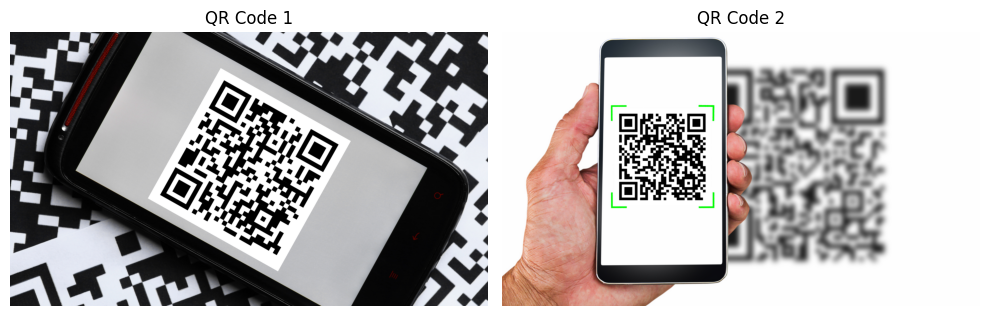

In [2]:
# Path ke folder data dan file gambar
image_path1 = os.path.join('data', 'qr1.png')
image_path2 = os.path.join('data', 'qr2.png')

# Memuat gambar. Jika file belum ada, notebook tetap berjalan memakai placeholder.
image1 = load_image_or_placeholder(image_path1, "QR Code 1")
image2 = load_image_or_placeholder(image_path2, "QR Code 2")

# Plot kedua gambar
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
axes[0].set_title('QR Code 1')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
axes[1].set_title('QR Code 2')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### **Membaca QR Code**

In [3]:
# Deteksi dan baca QR code menggunakan pyzbar
if PYZBAR_AVAILABLE:
    decoded_qr1 = decode(image1)
    print(decoded_qr1)
else:
    decoded_qr1 = []
    print("pyzbar belum tersedia, deteksi QR dengan pyzbar dilewati.")

pyzbar belum tersedia, deteksi QR dengan pyzbar dilewati.


In [4]:
# Deteksi menggunakan cv2.QRCodeDetector
qr_detector = cv2.QRCodeDetector()

qr_data, points, _ = qr_detector.detectAndDecode(image1)

print(f"Decoded QR Data: {qr_data}")
print(f"QR Code Points: {points}")

Decoded QR Data: 
QR Code Points: [[[ 841.78784  192.59317]
  [1292.1832   445.0876 ]
  [1040.       897.     ]
  [ 589.45557  643.1865 ]]]


### **Deteksi QR Code**

pyzbar belum tersedia, deteksi QR dengan pyzbar dilewati.


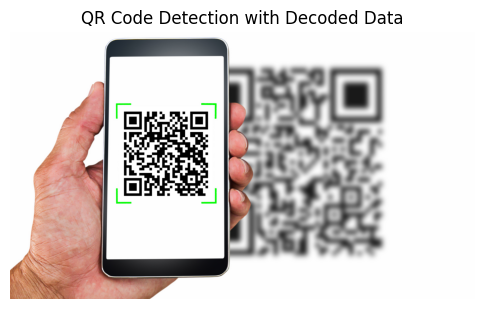

In [5]:
# Deteksi dan baca QR code menggunakan pyzbar
imagetext = image2.copy()

if PYZBAR_AVAILABLE:
    decoded_qr2 = decode(imagetext)
else:
    decoded_qr2 = []
    print("pyzbar belum tersedia, deteksi QR dengan pyzbar dilewati.")

# Loop melalui hasil deteksi
for obj in decoded_qr2:
    points = obj.polygon
    if len(points) == 4:
        pts = np.array([[p.x, p.y] for p in points], dtype=np.int32)
        cv2.polylines(imagetext, [pts], isClosed=True, color=(0, 255, 0), thickness=3)

    # Data yang didekodekan
    qr_data = obj.data.decode('utf-8')
    print(f"Decoded Data: {qr_data}")

    x, y = obj.rect.left, obj.rect.top
    cv2.putText(imagetext, qr_data, (x, y - 60), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 2)

# Tampilkan gambar dengan hasil pembacaan
show_image_bgr(imagetext, 'QR Code Detection with Decoded Data')

In [6]:
# Menggunakan kamera secara real-time untuk deteksi QR Code
# PERBAIKAN: agar Run All tidak macet, kamera tidak dijalankan otomatis.
# Jika ingin mencoba kamera, ubah RUN_CAMERA = True lalu jalankan CELL INI saja.

RUN_CAMERA = False
MAX_FRAMES = 300  # pembatas supaya tidak infinite loop

if not RUN_CAMERA:
    print("Cell kamera QR dilewati. Ubah RUN_CAMERA=True jika ingin menjalankan kamera secara manual.")
elif not PYZBAR_AVAILABLE:
    print("pyzbar belum tersedia, deteksi QR real-time tidak dapat dijalankan.")
else:
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("Error: Kamera tidak bisa dibuka")
    else:
        print("Pencet 'ESC' atau 'q' untuk keluar.")

        frame_count = 0
        while frame_count < MAX_FRAMES:
            ret, frame = cap.read()
            if not ret:
                print("Error: Gagal mengambil frame kamera.")
                break

            decoded_qrs = decode(frame)

            for obj in decoded_qrs:
                points = obj.polygon
                if len(points) == 4:
                    pts = np.array([[p.x, p.y] for p in points], dtype=np.int32)
                    cv2.polylines(frame, [pts], isClosed=True, color=(0, 255, 0), thickness=3)

                qr_data = obj.data.decode('utf-8')
                print(f"Decoded Data: {qr_data}")

                x, y = obj.rect.left, obj.rect.top
                cv2.putText(frame, qr_data, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

            cv2.imshow('QR Code Detection', frame)

            key = cv2.waitKey(1) & 0xFF
            if key == 27 or key == ord('q'):
                break

            frame_count += 1

        cap.release()
        cv2.destroyAllWindows()

Cell kamera QR dilewati. Ubah RUN_CAMERA=True jika ingin menjalankan kamera secara manual.


> **Pertanyaan:** Bagaimana jika untuk mendeteksi Barcode?

pyzbar belum tersedia, deteksi barcode dilewati.
Tidak ada barcode atau QR code terdeteksi.


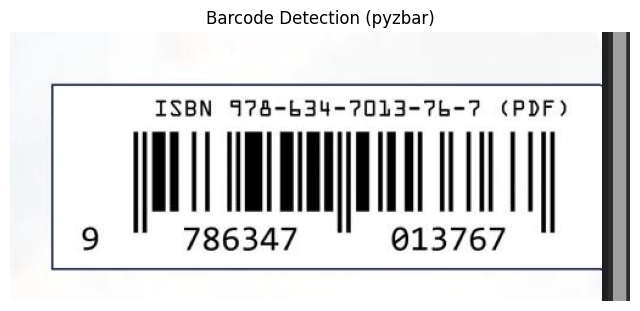

In [7]:
# Path gambar di folder data
image_path = os.path.join("data", "barcode.png")

# Baca gambar. Jika tidak ada, gunakan placeholder agar Run All tetap aman.
image = load_image_or_placeholder(image_path, "Barcode")

# Decode barcode / QR code
if PYZBAR_AVAILABLE:
    decoded_objects = decode(image)
else:
    decoded_objects = []
    print("pyzbar belum tersedia, deteksi barcode dilewati.")

if not decoded_objects:
    print("Tidak ada barcode atau QR code terdeteksi.")
else:
    for obj in decoded_objects:
        points = obj.polygon
        if len(points) == 4:
            pts = np.array([[p.x, p.y] for p in points], dtype=np.int32)
            cv2.polylines(image, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

        barcode_data = obj.data.decode('utf-8')
        barcode_type = obj.type
        print(f"Tipe: {barcode_type}, Data: {barcode_data}")

        x, y = obj.rect.left, obj.rect.top
        cv2.putText(image, f"{barcode_type}: {barcode_data}", (x, y - 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

show_image_bgr(image, "Barcode Detection (pyzbar)", figsize=(8, 6))

## **Landmark Wajah**

Landmark wajah adalah teknik untuk mengenali titik-titik penting pada wajah, seperti mata, hidung, bibir, dan rahang, biasanya berjumlah 68 titik atau lebih tergantung model. Deteksi ini dapat dilakukan menggunakan berbagai library seperti `Dlib`, `MediaPipe`, atau `OpenCV`, dan sering digunakan untuk analisis ekspresi, pelacakan wajah, atau efek augmented reality.

Setiap library memiliki jumlah dan posisi landmark wajah yang berbeda tergantung model yang digunakan:
1. `Dlib` → biasanya mendeteksi 68 landmark, mencakup detail rahang, mata, hidung, dan bibir
2. `MediaPipe` → jauh lebih detail, memiliki 468 titik (3D), cocok untuk aplikasi AR dan pelacakan ekspresi wajah secara real-time.
3. `OpenCV` → tidak punya deteksi landmark bawaan, tetapi bisa menggunakan model eksternal (seperti lbfmodel.yaml dari modul face OpenCV-contrib)

### **Membaca Landmark Wajah Menggunakan MediaPipe**

In [8]:
# Membaca landmark wajah menggunakan MediaPipe
# PERBAIKAN: kamera tidak dijalankan otomatis agar Run All tidak macet.
# Jika ingin mencoba kamera, ubah RUN_CAMERA = True lalu jalankan CELL INI saja.

RUN_CAMERA = False
MAX_FRAMES = 300

try:
    import mediapipe as mp
    MEDIAPIPE_AVAILABLE = True
except Exception as e:
    MEDIAPIPE_AVAILABLE = False
    print("MediaPipe belum tersedia, bagian landmark MediaPipe dilewati.")
    print("Detail:", e)

if not RUN_CAMERA:
    print("Cell kamera MediaPipe dilewati. Ubah RUN_CAMERA=True jika ingin menjalankan kamera secara manual.")
elif not MEDIAPIPE_AVAILABLE:
    print("MediaPipe belum tersedia, landmark wajah tidak dapat dijalankan.")
else:
    mp_drawing = mp.solutions.drawing_utils
    mp_face_mesh = mp.solutions.face_mesh

    face_mesh = mp_face_mesh.FaceMesh(
        static_image_mode=False,
        max_num_faces=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Kamera tidak bisa dibuka")
    else:
        print("Tekan 'q' untuk keluar")
        frame_count = 0

        while frame_count < MAX_FRAMES:
            ret, frame = cap.read()
            if not ret:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = face_mesh.process(rgb)
            h, w, _ = frame.shape

            if results.multi_face_landmarks:
                for face_landmarks in results.multi_face_landmarks:
                    mp_drawing.draw_landmarks(
                        image=frame,
                        landmark_list=face_landmarks,
                        connections=mp_face_mesh.FACEMESH_TESSELATION,
                        landmark_drawing_spec=None,
                        connection_drawing_spec=mp_drawing.DrawingSpec(
                            color=(0, 255, 0), thickness=1, circle_radius=1)
                    )

                    for idx, lm in enumerate(face_landmarks.landmark):
                        x, y = int(lm.x * w), int(lm.y * h)
                        cv2.putText(frame, str(idx), (x, y),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.25, (255, 0, 0), 1)

            cv2.imshow('Face Mesh MediaPipe', frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
            frame_count += 1

        cap.release()
        cv2.destroyAllWindows()

MediaPipe belum tersedia, bagian landmark MediaPipe dilewati.
Detail: No module named 'mediapipe'
Cell kamera MediaPipe dilewati. Ubah RUN_CAMERA=True jika ingin menjalankan kamera secara manual.


### **Membaca Landmark Wajah Menggunakan dlib**

In [9]:
# Persiapan model landmark Dlib
# PERBAIKAN: model tidak di-download otomatis saat Run All agar proses tidak lama/berhenti karena internet.

predictor_path = os.path.join(os.getcwd(), 'shape_predictor_68_face_landmarks.dat')
predictor_url = "https://github.com/davisking/dlib-models/raw/master/shape_predictor_68_face_landmarks.dat.bz2"
AUTO_DOWNLOAD_MODEL = False

if not DLIB_AVAILABLE:
    print("dlib belum tersedia, model landmark tidak digunakan.")
elif os.path.exists(predictor_path):
    print("Model landmark sudah tersedia di root directory.")
elif not AUTO_DOWNLOAD_MODEL:
    print("Model landmark belum ada, tetapi download otomatis dimatikan agar Run All tidak lama.")
    print("Jika ingin memakai dlib, download model secara manual atau ubah AUTO_DOWNLOAD_MODEL=True lalu jalankan cell ini saja.")
    print("URL model:", predictor_url)
else:
    import urllib.request
    import bz2

    print("Model landmark belum ada. Mengunduh dari GitHub...")
    compressed_path = predictor_path + ".bz2"
    urllib.request.urlretrieve(predictor_url, compressed_path)
    print("Ekstraksi file model...")
    with bz2.open(compressed_path, 'rb') as f_in, open(predictor_path, 'wb') as f_out:
        f_out.write(f_in.read())
    os.remove(compressed_path)
    print("Model berhasil diunduh dan diekstrak.")

dlib belum tersedia, model landmark tidak digunakan.


In [10]:
# Landmark wajah menggunakan dlib
# PERBAIKAN: kamera tidak dijalankan otomatis agar Run All tidak macet.
# Jika ingin mencoba kamera, ubah RUN_CAMERA = True lalu jalankan CELL INI saja.

RUN_CAMERA = False
MAX_FRAMES = 300

if not RUN_CAMERA:
    print("Cell kamera landmark dlib dilewati. Ubah RUN_CAMERA=True jika ingin menjalankan kamera secara manual.")
elif not DLIB_AVAILABLE:
    print("dlib belum tersedia, landmark dlib tidak dapat dijalankan.")
elif not os.path.exists(predictor_path):
    print("Model shape_predictor_68_face_landmarks.dat belum tersedia, landmark dlib tidak dapat dijalankan.")
else:
    detector = dlib.get_frontal_face_detector()
    predictor = dlib.shape_predictor(predictor_path)

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Kamera tidak bisa dibuka")
    else:
        print("Tekan 'q' untuk keluar")
        frame_count = 0

        while frame_count < MAX_FRAMES:
            ret, frame = cap.read()
            if not ret:
                print("Error: Gagal mengambil frame kamera.")
                break

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = detector(gray)

            for (i, face) in enumerate(faces):
                shape = predictor(gray, face)
                landmarks = np.array([[shape.part(j).x, shape.part(j).y] for j in range(68)])

                for idx, (lx, ly) in enumerate(landmarks):
                    cv2.circle(frame, (lx, ly), 1, (255, 0, 0), -1)
                    cv2.putText(frame, str(idx), (lx + 2, ly - 2),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.25, (255, 255, 0), 1, cv2.LINE_AA)

            cv2.imshow("Face Landmark (Dlib Style)", frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
            frame_count += 1

        cap.release()
        cv2.destroyAllWindows()

Cell kamera landmark dlib dilewati. Ubah RUN_CAMERA=True jika ingin menjalankan kamera secara manual.


## **Image Overlay Ke Wajah**

In [11]:
# Image overlay kacamata ke wajah secara real-time
# PERBAIKAN: kamera tidak dijalankan otomatis agar Run All tidak macet.
# Jika ingin mencoba kamera, ubah RUN_CAMERA = True lalu jalankan CELL INI saja.

RUN_CAMERA = False
MAX_FRAMES = 300

glasses_path = os.path.join('data', 'glasses.png')
glasses = cv2.imread(glasses_path, cv2.IMREAD_UNCHANGED)

if not RUN_CAMERA:
    print("Cell kamera overlay kacamata dilewati. Ubah RUN_CAMERA=True jika ingin menjalankan kamera secara manual.")
elif not DLIB_AVAILABLE:
    print("dlib belum tersedia, overlay kacamata tidak dapat dijalankan.")
elif not os.path.exists(predictor_path):
    print("Model shape_predictor_68_face_landmarks.dat belum tersedia, overlay kacamata tidak dapat dijalankan.")
elif glasses is None:
    print("Error: Gambar kacamata tidak ditemukan di", glasses_path)
else:
    detector = dlib.get_frontal_face_detector()
    predictor = dlib.shape_predictor(predictor_path)

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Kamera tidak bisa dibuka")
    else:
        print("Tekan 'q' untuk keluar")
        frame_count = 0

        while frame_count < MAX_FRAMES:
            ret, frame = cap.read()
            if not ret:
                break

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = detector(gray)

            for face in faces:
                landmarks = predictor(gray, face)
                left_eye = np.array([landmarks.part(36).x, landmarks.part(36).y])
                right_eye = np.array([landmarks.part(45).x, landmarks.part(45).y])

                eye_distance = np.linalg.norm(right_eye - left_eye)
                glasses_width = int(2 * eye_distance)
                glasses_height = int(glasses.shape[0] * (glasses_width / glasses.shape[1]))
                eye_center = np.mean([left_eye, right_eye], axis=0).astype(int)

                x1 = int(eye_center[0] - glasses_width / 2)
                y1 = int(eye_center[1] - glasses_height / 2)
                x2, y2 = x1 + glasses_width, y1 + glasses_height

                if x1 < 0 or y1 < 0 or x2 > frame.shape[1] or y2 > frame.shape[0]:
                    continue

                resized_glasses = cv2.resize(glasses, (glasses_width, glasses_height))

                if resized_glasses.shape[2] == 4:
                    alpha_glasses = resized_glasses[:, :, 3] / 255.0
                    for c in range(3):
                        frame[y1:y2, x1:x2, c] = (
                            alpha_glasses * resized_glasses[:, :, c] +
                            (1 - alpha_glasses) * frame[y1:y2, x1:x2, c]
                        )

            cv2.imshow("Glasses Overlay", frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
            frame_count += 1

        cap.release()
        cv2.destroyAllWindows()

Cell kamera overlay kacamata dilewati. Ubah RUN_CAMERA=True jika ingin menjalankan kamera secara manual.


In [12]:
# Image overlay lipstick ke wajah secara real-time
# PERBAIKAN: kamera tidak dijalankan otomatis agar Run All tidak macet.
# Jika ingin mencoba kamera, ubah RUN_CAMERA = True lalu jalankan CELL INI saja.

RUN_CAMERA = False
MAX_FRAMES = 300

predictor_path = os.path.join("shape_predictor_68_face_landmarks.dat")
lipstick_path = os.path.join('data', 'lipstick.png')
lipstick = cv2.imread(lipstick_path, cv2.IMREAD_UNCHANGED)

if not RUN_CAMERA:
    print("Cell kamera overlay lipstick dilewati. Ubah RUN_CAMERA=True jika ingin menjalankan kamera secara manual.")
elif not DLIB_AVAILABLE:
    print("dlib belum tersedia, overlay lipstick tidak dapat dijalankan.")
elif not os.path.exists(predictor_path):
    print("Model shape_predictor_68_face_landmarks.dat belum tersedia, overlay lipstick tidak dapat dijalankan.")
elif lipstick is None:
    print("Error: Gambar lipstick tidak ditemukan di", lipstick_path)
else:
    detector = dlib.get_frontal_face_detector()
    predictor = dlib.shape_predictor(predictor_path)

    if lipstick.shape[2] == 4:
        b, g, r, a = cv2.split(lipstick)
        lipstick_rgb = cv2.merge((b, g, r))
        alpha = a / 255.0
    else:
        lipstick_rgb = lipstick
        alpha = np.ones(lipstick.shape[:2], dtype=float)

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Kamera tidak bisa dibuka")
    else:
        print("Tekan 'q' untuk keluar")
        frame_count = 0

        while frame_count < MAX_FRAMES:
            ret, frame = cap.read()
            if not ret:
                break

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = detector(gray)

            for face in faces:
                landmarks = predictor(gray, face)

                left_lip = np.array([landmarks.part(48).x, landmarks.part(48).y])
                right_lip = np.array([landmarks.part(54).x, landmarks.part(54).y])
                top_lip = np.array([landmarks.part(51).x, landmarks.part(51).y])
                bottom_lip = np.array([landmarks.part(57).x, landmarks.part(57).y])

                lip_width = int(np.linalg.norm(right_lip - left_lip) * 1.3)
                lip_height = int(np.linalg.norm(bottom_lip - top_lip) * 2.0)
                lip_center = np.mean([left_lip, right_lip, top_lip, bottom_lip], axis=0).astype(int)

                x1 = int(lip_center[0] - lip_width / 2)
                y1 = int(lip_center[1] - lip_height / 2)
                x2, y2 = x1 + lip_width, y1 + lip_height

                if x1 < 0 or y1 < 0 or x2 > frame.shape[1] or y2 > frame.shape[0]:
                    continue

                resized_lipstick = cv2.resize(lipstick_rgb, (lip_width, lip_height))
                resized_alpha = cv2.resize(alpha, (lip_width, lip_height))

                for c in range(3):
                    frame[y1:y2, x1:x2, c] = (
                        resized_alpha * resized_lipstick[:, :, c] +
                        (1 - resized_alpha) * frame[y1:y2, x1:x2, c]
                    )

            cv2.imshow("Lipstick Overlay", frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
            frame_count += 1

        cap.release()
        cv2.destroyAllWindows()

Cell kamera overlay lipstick dilewati. Ubah RUN_CAMERA=True jika ingin menjalankan kamera secara manual.
